# Handwritten Bengali Numeral Recognition (Deep CNN)

This notebook provides a comprehensive research pipeline for recognizing handwritten Bengali digits (0-9) using the **CMATERdb 3.1.1** dataset.

### **Advanced Features:**
- **Deep 5-Layer CNN**: Features Batch Normalization, Dropout, and 256 filters.
- **AI Diagnostics**: Includes Training Curves, Filter Visualizations, and Confusion Matrices.
- **Data Augmentation**: Robustness against rotation and translation.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Dataset Exploration & Visualization

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_20792/2149181039.py:15: UserWarning: Glyph 2534 (\N{BENGALI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_20792/2149181039.py:15: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_20792/2149181039.py:15: UserWarning: Glyph 2535 (\N{BENGALI DIGIT ONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_20792/2149181039.py:15: UserWarning: Glyph 2536 (\N{BENGALI DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_20792/2149181039.py:15: UserWarning: Glyph 2537 (\N{BENGALI DIGIT THREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_20792/2149181039.py:1

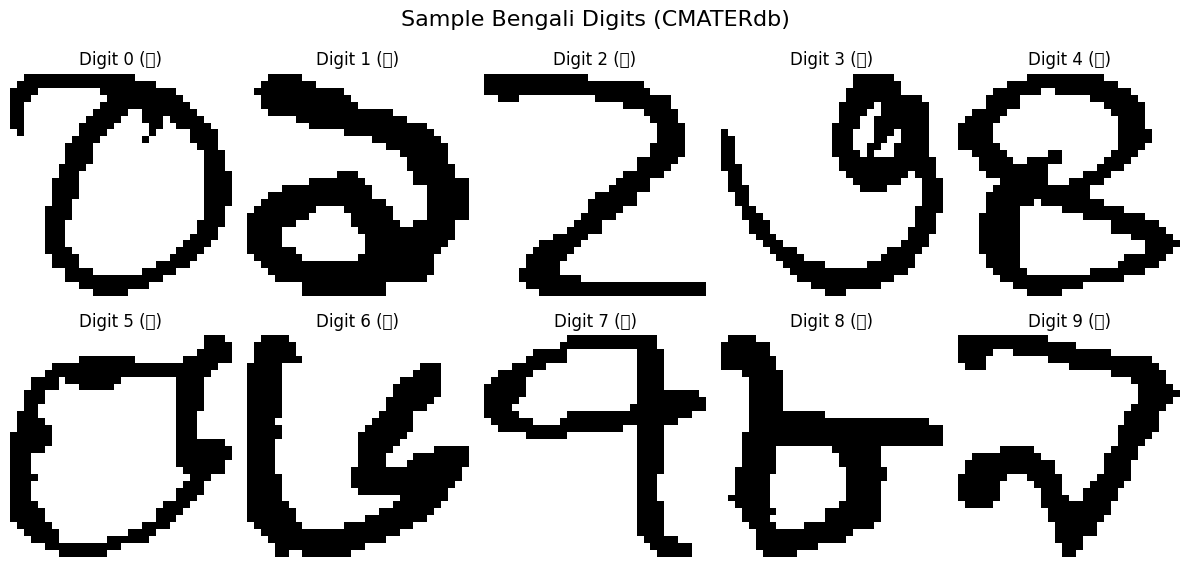

In [2]:
def visualize_dataset():
    data = np.load('dataset/training-images.npz')
    images = data['images']
    labels = data['labels']
    bengali_digits = ['০', '১', '২', '৩', '৪', '৫', '৬', '৭', '৮', '৯']
    
    plt.figure(figsize=(12, 6))
    for i in range(10):
        idx = np.where(labels == i)[0][0]
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[idx])
        plt.title(f"Digit {i} ({bengali_digits[i]})")
        plt.axis('off')
    plt.suptitle("Sample Bengali Digits (CMATERdb)", fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_dataset()

## 2. Data Preparation & Augmentation

In [3]:
class BengaliDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        image, label = self.images[idx], self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

def get_loaders():
    train_data = np.load('dataset/training-images.npz')
    test_data = np.load('dataset/testing-images.npz')

    train_imgs = torch.tensor(train_data['images'].astype(np.float32) / 255.0).permute(0, 3, 1, 2)
    test_imgs = torch.tensor(test_data['images'].astype(np.float32) / 255.0).permute(0, 3, 1, 2)
    train_lbls, test_lbls = torch.tensor(train_data['labels']), torch.tensor(test_data['labels'])

    train_transform = transforms.Compose([transforms.RandomRotation(10), transforms.RandomAffine(0, (0.1, 0.1))])
    
    train_loader = DataLoader(BengaliDataset(train_imgs, train_lbls, train_transform), batch_size=64, shuffle=True)
    test_loader = DataLoader(BengaliDataset(test_imgs, test_lbls), batch_size=64, shuffle=False)
    return train_loader, test_loader

train_loader, test_loader = get_loaders()

## 3. Deep CNN Architecture

In [4]:
class BengaliDigitCNN(nn.Module):
    def __init__(self):
        super(BengaliDigitCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 256 * 4 * 4)
        return self.classifier(x)

model = BengaliDigitCNN().to(device)

## 4. Training with Diagnostics
We'll track the loss and accuracy history for plotting.

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history = {'loss': [], 'acc': []}
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0); correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    avg_acc = 100. * correct / total
    history['loss'].append(avg_loss); history['acc'].append(avg_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.2f}%")
    scheduler.step(avg_loss)

Epoch 1/20 | Loss: 0.8745 | Acc: 86.88%


Epoch 2/20 | Loss: 0.7213 | Acc: 93.92%


Epoch 3/20 | Loss: 0.6679 | Acc: 96.10%


Epoch 4/20 | Loss: 0.6519 | Acc: 96.74%


Epoch 5/20 | Loss: 0.6395 | Acc: 97.34%


...

Epoch 16/20 | Loss: 0.5807 | Acc: 99.06%


Epoch 17/20 | Loss: 0.5823 | Acc: 99.14%


Epoch 18/20 | Loss: 0.5816 | Acc: 99.24%


Epoch 19/20 | Loss: 0.5801 | Acc: 99.00%


Epoch 20/20 | Loss: 0.5753 | Acc: 99.44%


## 5. Visualizing Training Curves

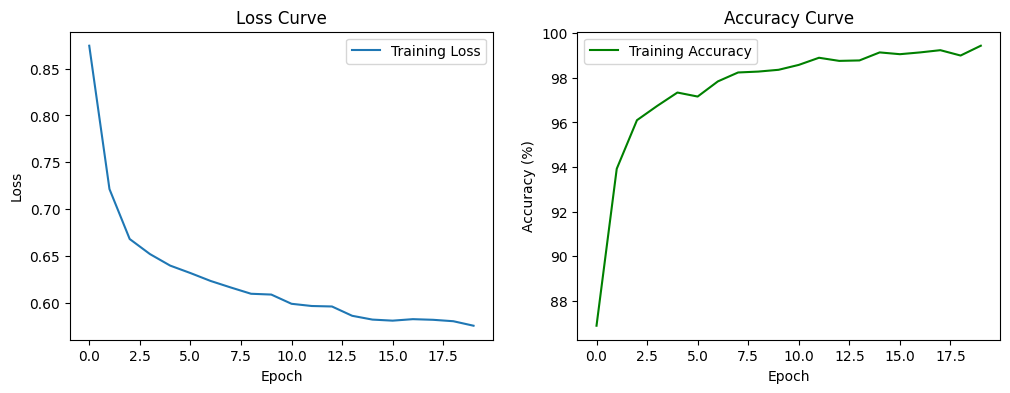

In [6]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.title('Loss Curve'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Training Accuracy', color='green')
plt.title('Accuracy Curve'); plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend()
plt.show()

## 6. CNN 

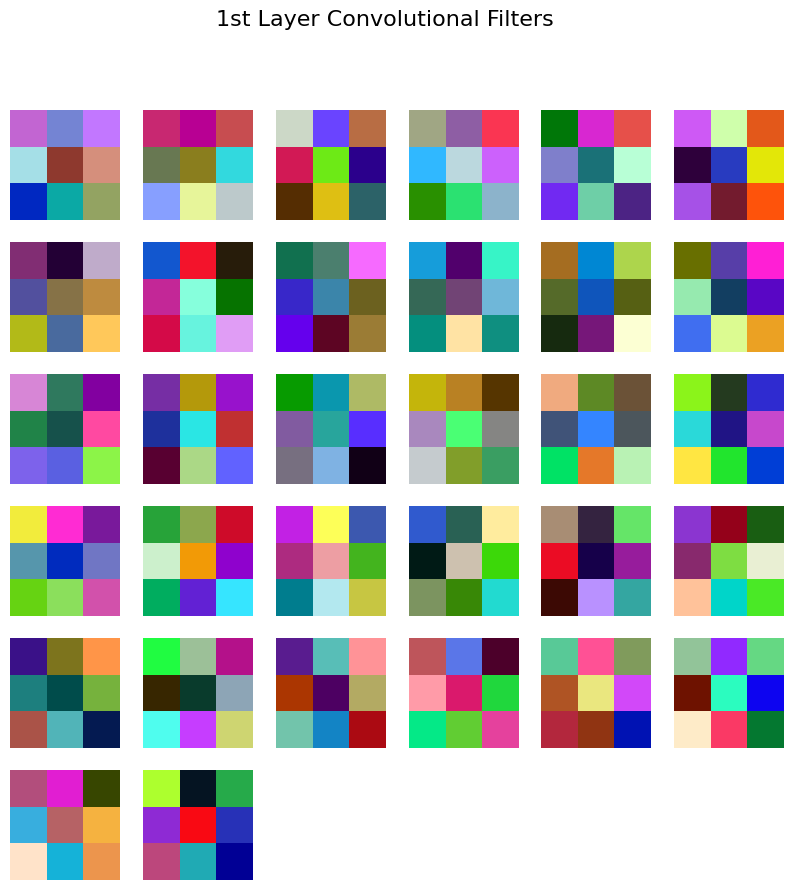

In [7]:
def plot_filters(model):
    filters = model.features[0].weight.data.cpu().numpy()
    plt.figure(figsize=(10, 10))
    for i in range(min(32, filters.shape[0])):
        plt.subplot(6, 6, i + 1)
        f = filters[i].transpose(1, 2, 0)
        f = (f - f.min()) / (f.max() - f.min())
        plt.imshow(f)
        plt.axis('off')
    plt.suptitle("1st Layer Convolutional Filters", fontsize=16)
    plt.show()

plot_filters(model)

## 7. Confusion Matrix

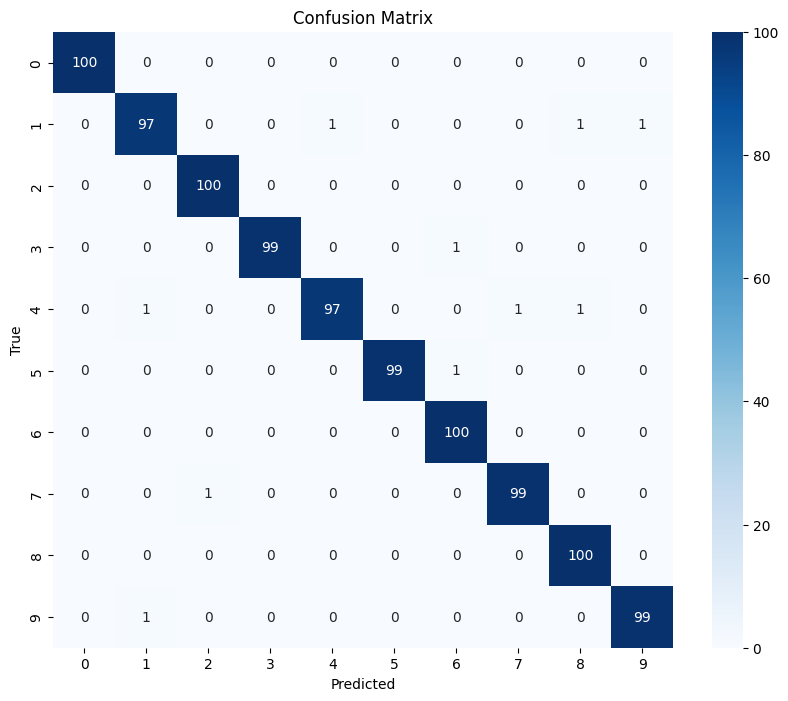

In [8]:
def plot_confusion_matrix(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            y_true.extend(labels.numpy()); y_pred.extend(predicted.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, test_loader)